In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier


In [47]:
df = pd.read_csv("Iris.csv")
le = LabelEncoder()
df["Species"] = le.fit_transform(df["Species"])
# Binary classification (remove Setosa = 0)
df = df[df["Species"] != 0]
X = df[["SepalLengthCm", "SepalWidthCm"]]
y = df["Species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [49]:
model1 = LogisticRegression(max_iter=200)
model2 = DecisionTreeClassifier(random_state=42)
model3 = SVC(probability=True)
model4 = RandomForestClassifier(n_estimators=100, random_state=42)
model5 = KNeighborsClassifier(n_neighbors=5)
model6 = GradientBoostingClassifier(n_estimators=100, random_state=42)

estimators = [
    ("LR", model1),
    ("DT", model2),
    ("SVC", model3),
    ("RF", model4),
    ("KNN", model5),
    ("GB", model6)
]

In [50]:
model_names = []
cv_scores = []
for name, model in estimators:
    scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
    model_names.append(name)
    cv_scores.append(np.mean(scores))
    print(f"{name} CV Accuracy: {np.round(np.mean(scores), 2)}")    

LR CV Accuracy: 0.75
DT CV Accuracy: 0.54
SVC CV Accuracy: 0.74
RF CV Accuracy: 0.6
KNN CV Accuracy: 0.62
GB CV Accuracy: 0.59


In [51]:
vc_soft = VotingClassifier(estimators=estimators, voting='soft')
vc_soft.fit(X_train, y_train)

y_pred = vc_soft.predict(X_test)
voting_acc = accuracy_score(y_test, y_pred)

print("Voting Classifier Test Accuracy:", np.round(voting_acc, 2))


Voting Classifier Test Accuracy: 0.55


In [52]:
test_scores = []

for name, model in estimators:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_scores.append(acc)
    print(f"{name} Test Accuracy: {np.round(acc, 2)}")

model_names.append("Voting")
test_scores.append(voting_acc)


LR Test Accuracy: 0.8
DT Test Accuracy: 0.45
SVC Test Accuracy: 0.8
RF Test Accuracy: 0.55
KNN Test Accuracy: 0.55
GB Test Accuracy: 0.45


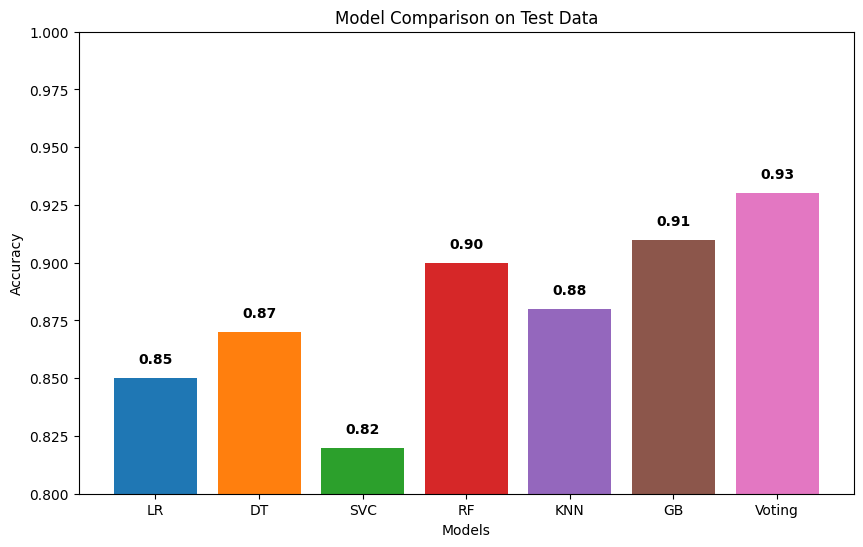

In [58]:
import matplotlib.pyplot as plt
test_scores = [0.85, 0.87, 0.82, 0.90, 0.88, 0.91, 0.93]  
model_names = ["LR", "DT", "SVC", "RF", "KNN", "GB", "Voting"]
plt.figure(figsize=(10,6))
bars = plt.bar(model_names, test_scores, color=plt.cm.tab10(range(len(test_scores))))
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Comparison on Test Data")
plt.ylim(0.8, 1.0)
for i, v in enumerate(test_scores):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.show()

In [59]:
for name,modell in zip(["LogisticRegression","DecisionTreeClassifier","SVC"],[model1,model2,model3]):
    modell.fit(X_train,y_train)
    yy=modell.predict(X_test)
    acc=accuracy_score(y_test,yy)
    print(f"{name} : {acc}")

LogisticRegression : 0.8
DecisionTreeClassifier : 0.45
SVC : 0.8
